In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from torchvision import transforms
from PIL import Image
from io import BytesIO
import requests

imgs = [
    "https://learnopencv.com/wp-content/uploads/2019/05/dog.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/01/strawberries.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/01/automotive.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/06/Getting_Started_with_Opencv.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/06/sample.jpg",
    "https://t3.ftcdn.net/jpg/01/97/11/64/360_F_197116416_hpfTtXSoJMvMqU99n6hGP4xX0ejYa4M7.jpg",
    "https://s1.elespanol.com/2023/03/05/madrid/capital/746185587_231400045_1706x960.jpg"
]

imagenes = []

for url in imgs:
    response = requests.get(url, timeout=20)
    response.raise_for_status()

    imagen = Image.open(BytesIO(response.content)).convert("RGB")
    imagenes.append(imagen)

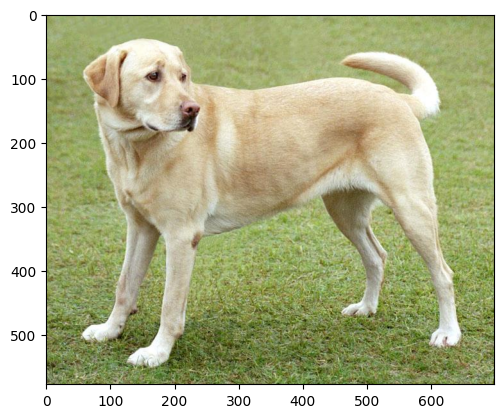

In [ ]:
plt.imshow(imagenes[0])


In [ ]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop((190,250)),
    transforms.ToTensor(),
    transforms.Normalize( mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#El método transform.ToTensor convierte las dimensiones de (H,W,C) a las dimensiones (C,H,W).
#El método unsqueeze( arreglo, 0), agrega una dimensión en la posición 0.
#El método CAT pega las imágenes un un único arreglo por medio de la dimensión 0 en este caso.

batch_t=torch.cat([torch.unsqueeze(transform(im),0) for im in img], axis=0)
print(batch_t.shape)

torch.Size([5, 3, 190, 250])


Dimensiones de la imagen inicial: (577, 700, 3)


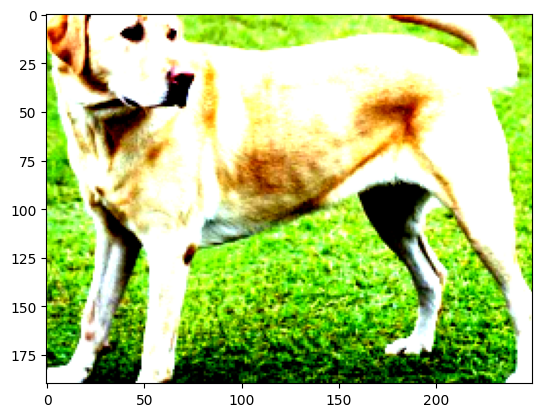

In [ ]:
print('Dimensiones de la imagen inicial:',np.asarray(img[0]).shape)
xi=transform(img[0])
plt.imshow(xi.permute(1,2,0).numpy())